<a href="https://colab.research.google.com/github/palak0626/predictive-analysis/blob/main/datasimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!pip install cantera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.7 MB/s eta 0:00:00


In [4]:
import cantera as ct

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# cantera

In [5]:
temps = []
pressures = []
times = []

for i in range(300):
    gas = ct.Solution('gri30.yaml')


    T = np.random.uniform(900, 1500)
    P = np.random.uniform(1, 5) * ct.one_atm

    gas.TPX = T, P, 'CH4:1, O2:2'

    reactor = ct.IdealGasReactor(gas)
    sim = ct.ReactorNet([reactor])

    t = 0
    for step in range(10):
        t += 1e-4
        sim.advance(t)

    temps.append(reactor.T)
    pressures.append(reactor.thermo.P)
    times.append(t)

print("Cantera simulation done!")

/tmp/ipykernel_3802/3351469133.py:14: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas)
/tmp/ipykernel_3802/3351469133.py:23: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  pressures.append(reactor.thermo.P)


Cantera simulation done!


In [6]:
n = 1000


age = np.random.randint(18, 60, n)
experience = np.random.randint(0, 20, n)


temp_full = np.random.choice(temps, n)
pressure_full = np.random.choice(pressures, n)
time_full = np.random.choice(times, n)


target = ((temp_full > 1200) & (pressure_full > 2 * ct.one_atm)).astype(int)


data = pd.DataFrame({
    "Temperature": temp_full,
    "Pressure": pressure_full,
    "Time": time_full,
    "Age": age,
    "Experience": experience,
    "Target": target
})

data.head()

,Temperature,Pressure,Time,Age,Experience,Target
0,938.898600,3.642507e+05,0.001,37,19,0
1,3671.245854,3.730079e+05,0.001,38,5,1
2,938.517664,1.420161e+05,0.001,55,6,0
3,3469.442341,8.159253e+05,0.001,31,17,1
4,1028.598187,1.447999e+06,0.001,32,6,0


In [7]:
X = data.drop("Target", axis=1)
y = data["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

results

{'Logistic Regression': 0.775,
 'Decision Tree': 1.0,
 'Random Forest': 1.0,
 'SVM': 0.61,
 'KNN': 0.725}

In [9]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Logistic Regression,0.775
1,Decision Tree,1.000
2,Random Forest,1.000
3,SVM,0.610
4,KNN,0.725


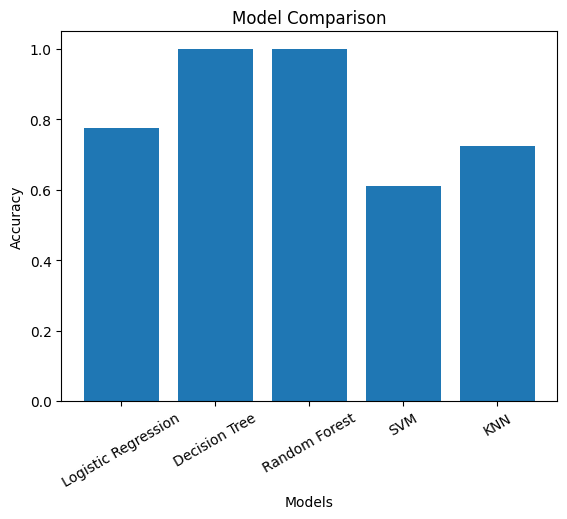

In [10]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [11]:
best_model = results_df.loc[results_df["Accuracy"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model       Decision Tree
Accuracy              1.0
Name: 1, dtype: object
